### Imports

In [35]:
import json
import os
import pandas as pd

from utils_MS import *

# %load_ext autotime

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

import plotly.graph_objects as go
import sys
import torch
import torch.nn.functional as F
import os.path as osp

%matplotlib inline
from IPython import display
from IPython.display import HTML
from matplotlib import animation

from sklearn.cluster import HDBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

from torch_geometric.datasets import KarateClub, Planetoid
from torch_geometric.data import Data
from torch import nn, optim, Tensor
from torch_geometric.utils import structured_negative_sampling, to_networkx
from torch_geometric.nn.conv.gcn_conv import gcn_norm
from torch_geometric.nn import LGConv, Node2Vec, GCNConv, GATv2Conv, SAGEConv
from torch_geometric.nn import global_mean_pool, global_add_pool
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU, Dropout
import torch_geometric.transforms as T

from tqdm import tqdm

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, silhouette_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import kneighbors_graph

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

In [41]:
# def run(params):

### Parameters

In [42]:
""" try:
    dir = os.path.dirname(os.path.abspath(__file__))
except:
    dir = os.getcwd()
print(dir) """

' try:\n    dir = os.path.dirname(os.path.abspath(__file__))\nexcept:\n    dir = os.getcwd()\nprint(dir) '

In [43]:
dict_dataset = {
    1: ["Mentos_2_process_NormalizationFiltered_format", ["Orange"]], # new mentos,  for Metabolomics
    2: ["deybis_filter_september_2br_3ar_format", ["SecoAmazonas"]],
    3: ["deybis_filter_december_2br_3ar_format", ["SecoAmazonas"]],
    4: ["deybis_filter_september_2br_10ar_format", ["SecoAmazonas"]],
    5: ["deybis_filter_december_2br_10ar_format", ["SecoAmazonas"]], # for Metabolomics
    6: ["deybis_filter_september_min_2br_3ar_format", ["SecoAmazonas"]],
    7: ["deybis_filter_december_min_2br_3ar_format", ["SecoAmazonas"]],
    8: ["vanessa_december_2br_3ar_format", ["SecoAmazonas"]],
    9: ["Pablo_2br_nar_format", ["AR"]],
    10: ["Pablo_2br_14ar_format", ["AR"]],
}
dataset = dict_dataset[9] # change
dataset

['Pablo_2br_nar_format', ['AR']]

In [44]:
params = {
    "exp": "exp0", # Change
    "methods": ["t-gae"], # ["vgae-base", "argva-base", "vgae-line", "dgi-tran", "t-gae"],
    "data_variations": ["none"],
    "has_transformation": True, # True or False
    "controls": dataset[1],
    "dimension": 64,
    "threshold_corr": 0.5,
    "threshold_log2": 0,
    "alpha": 0.05,
    "iterations": 1,
    "raw_data_file": dataset[0],
    "groups_id_no": ["Blank", "QC", "Std"],
    "sensitivity": False, # False: f1 (selectivity), True: f1 (selectivity), f2 (sensitivity)
    "obs": "",
    "seeds": [41, 42, 43, 44, 45, 46],
    
    "from": "python",
    "cuda": 0,
    "epochs": 100,
    "lr": 0.0001,
    "weight_decay": 1e-4,
    "patience": 10,
    "contamination": 0.1, # float in (0., 0.5)
    "n_jobs": 1, # -1 all
}

In [45]:
""" dir_path = "experiments/output"
res = sorted(os.listdir(dir_path))
n = len(res)
exp = "exp{}".format(n) """

exp = str(params["exp"])
exp

'exp0'

### Load dataset

In [46]:
exp = "exp9"
file = open("experiments/output/{}/parameters.json".format(exp))
params = json.load(file)

exp = params["exp"]

print("Exp:\t\t", exp)

methods = params["methods"]
print("Methods:\t", methods)

data_variations = params["data_variations"]
print("Data variations:", data_variations)

controls = params["controls"]
print("Control:\t", controls)

groups_id = params["groups_id"]
# groups_id = ['SecoAmazonas', 'SecoCusco', 'SecoSanMartin', 'FrescoAmazonas', 'FrescoCusco', 'FrescoSanMartin']
print("Groups id:\t", groups_id)

subgroups_id = params["subgroups_id"]
print("Subgroups id:\t", subgroups_id)

groups = params["groups"]
print("Groups:\t\t", groups)

# encoders = ["GIN", "GINE"]
encoders = ["GIN"]

Exp:		 exp9
Methods:	 ['t-gae']
Data variations: ['none']
Control:	 ['AR']
Groups id:	 ['AR', 'CRS', 'OSA', 'LPRD', 'SGB', 'LSNB', 'RCC', 'BC', 'BPH', 'PCa', 'PD']
Subgroups id:	 {'AR': ['1', '2'], 'CRS': ['1', '2'], 'OSA': ['1', '2'], 'LPRD': ['1', '2'], 'SGB': ['1', '2'], 'LSNB': ['1', '2'], 'RCC': ['1', '2'], 'BC': ['1', '2'], 'BPH': ['1', '2'], 'PCa': ['1', '2'], 'PD': ['1', '2']}
Groups:		 [['AR', 'CRS'], ['AR', 'OSA'], ['AR', 'LPRD'], ['AR', 'SGB'], ['AR', 'LSNB'], ['AR', 'RCC'], ['AR', 'BC'], ['AR', 'BPH'], ['AR', 'PCa'], ['AR', 'PD']]


In [47]:
params["raw_data_file"] = "Pablo_all" # Obs

In [48]:
# load dataset groups
if params["from"] == "python":
    df_raw = pd.read_csv("experiments/raw_data/{}.csv".format(params["raw_data_file"]), delimiter=",")
elif params["from"] == "drf":
    df_raw = pd.read_csv("{}".format(params["raw_data_file"]), delimiter=",") # from DRF
df_raw

,Alignment ID,Average Rt,Average Mz,Metabolite name,AR_2E,AR_A210050,AR_A210051,AR_A210052,AR_A210054,AR_A210055,...,health_S02,health_S03,health_S04,health_S05,health_S06,health_S07,health_S08,health_S09,health_S10,health_S11
0,0,1.0,69.99951,Unknown,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,...,-0.323119,-0.301910,0.197998,-0.335759,-0.189232,-0.178399,-0.167625,-0.156910,-0.146251,0.213709
1,1,1.0,70.04025,Unknown,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,...,2.399864,2.421034,2.920018,4.695384,2.305521,2.316318,2.327056,2.337737,2.348360,2.697953
2,2,1.0,70.04151,Unknown,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,...,1.138489,1.155690,1.561112,1.009244,1.087138,1.092894,1.098620,1.104314,1.109978,1.301124
3,3,1.0,70.04908,Unknown,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,...,1.880134,1.900361,2.377108,1.966174,2.072484,2.080343,2.088160,2.095934,2.103668,2.358324
4,4,1.0,70.06267,Unknown,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,...,1.507450,1.525407,1.944987,1.679141,1.785358,1.793208,1.801015,1.808780,1.816503,2.077151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7352,7352,1.0,-754.83684,Unknown,2.738059,0.896303,1.176526,1.472825,1.572100,1.654756,...,2.453639,2.471184,2.884720,2.212016,2.353521,2.363982,2.374387,2.384735,2.395029,2.733992
7353,7353,1.0,-759.76498,Unknown,0.955142,-0.859490,-0.578136,-0.280639,-0.180963,-0.097972,...,0.703362,0.720978,1.136193,0.585522,0.676921,0.683676,0.690394,0.697076,0.703721,0.928008
7354,7354,1.0,-766.05312,Unknown,2.064099,0.180589,0.471322,0.778735,0.881734,0.967491,...,1.794745,1.812949,2.241999,1.546931,1.691106,1.701764,1.712365,1.722909,1.733396,2.087574
7355,7355,1.0,-863.46939,Unknown,0.995853,-0.396155,-0.179612,0.049355,0.126071,0.189944,...,0.819948,0.833506,1.153076,0.697635,0.776719,0.782563,0.788376,0.794157,0.799907,0.993974


### Format dataset

In [49]:
# has transformation
""" columns_data = list(df_raw.columns)[4:]
if params["has_transformation"]:
    print("transformation")
    for column in columns_data:
        df_raw[column] = df_raw[column].apply(lambda x: 10**x)
df_raw """

' columns_data = list(df_raw.columns)[4:]\nif params["has_transformation"]:\n    print("transformation")\n    for column in columns_data:\n        df_raw[column] = df_raw[column].apply(lambda x: 10**x)\ndf_raw '

In [50]:
# concat
df_join_raw = pd.concat([
    df_raw.iloc[:, :]], axis=1)
df_join_raw.set_index("Alignment ID", inplace=True)
df_join_raw

,Average Rt,Average Mz,Metabolite name,AR_2E,AR_A210050,AR_A210051,AR_A210052,AR_A210054,AR_A210055,AR_A210056,...,health_S02,health_S03,health_S04,health_S05,health_S06,health_S07,health_S08,health_S09,health_S10,health_S11
Alignment ID,,,,,,,,,,,,,,,,,,,,,
0,1.0,69.99951,Unknown,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,-1.213064,...,-0.323119,-0.301910,0.197998,-0.335759,-0.189232,-0.178399,-0.167625,-0.156910,-0.146251,0.213709
1,1.0,70.04025,Unknown,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,1.525385,...,2.399864,2.421034,2.920018,4.695384,2.305521,2.316318,2.327056,2.337737,2.348360,2.697953
2,1.0,70.04151,Unknown,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,0.323632,...,1.138489,1.155690,1.561112,1.009244,1.087138,1.092894,1.098620,1.104314,1.109978,1.301124
3,1.0,70.04908,Unknown,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,0.848291,...,1.880134,1.900361,2.377108,1.966174,2.072484,2.080343,2.088160,2.095934,2.103668,2.358324
4,1.0,70.06267,Unknown,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,0.603536,...,1.507450,1.525407,1.944987,1.679141,1.785358,1.793208,1.801015,1.808780,1.816503,2.077151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7352,1.0,-754.83684,Unknown,2.738059,0.896303,1.176526,1.472825,1.572100,1.654756,1.725780,...,2.453639,2.471184,2.884720,2.212016,2.353521,2.363982,2.374387,2.384735,2.395029,2.733992
7353,1.0,-759.76498,Unknown,0.955142,-0.859490,-0.578136,-0.280639,-0.180963,-0.097972,-0.026661,...,0.703362,0.720978,1.136193,0.585522,0.676921,0.683676,0.690394,0.697076,0.703721,0.928008
7354,1.0,-766.05312,Unknown,2.064099,0.180589,0.471322,0.778735,0.881734,0.967491,1.041179,...,1.794745,1.812949,2.241999,1.546931,1.691106,1.701764,1.712365,1.722909,1.733396,2.087574


In [51]:
# split
df_join_raw = df_join_raw.rename_axis(None)
# df_join_raw = df_join_raw.iloc[:, 2:]
df_join_raw

,Average Rt,Average Mz,Metabolite name,AR_2E,AR_A210050,AR_A210051,AR_A210052,AR_A210054,AR_A210055,AR_A210056,...,health_S02,health_S03,health_S04,health_S05,health_S06,health_S07,health_S08,health_S09,health_S10,health_S11
0,1.0,69.99951,Unknown,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,-1.213064,...,-0.323119,-0.301910,0.197998,-0.335759,-0.189232,-0.178399,-0.167625,-0.156910,-0.146251,0.213709
1,1.0,70.04025,Unknown,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,1.525385,...,2.399864,2.421034,2.920018,4.695384,2.305521,2.316318,2.327056,2.337737,2.348360,2.697953
2,1.0,70.04151,Unknown,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,0.323632,...,1.138489,1.155690,1.561112,1.009244,1.087138,1.092894,1.098620,1.104314,1.109978,1.301124
3,1.0,70.04908,Unknown,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,0.848291,...,1.880134,1.900361,2.377108,1.966174,2.072484,2.080343,2.088160,2.095934,2.103668,2.358324
4,1.0,70.06267,Unknown,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,0.603536,...,1.507450,1.525407,1.944987,1.679141,1.785358,1.793208,1.801015,1.808780,1.816503,2.077151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7352,1.0,-754.83684,Unknown,2.738059,0.896303,1.176526,1.472825,1.572100,1.654756,1.725780,...,2.453639,2.471184,2.884720,2.212016,2.353521,2.363982,2.374387,2.384735,2.395029,2.733992
7353,1.0,-759.76498,Unknown,0.955142,-0.859490,-0.578136,-0.280639,-0.180963,-0.097972,-0.026661,...,0.703362,0.720978,1.136193,0.585522,0.676921,0.683676,0.690394,0.697076,0.703721,0.928008
7354,1.0,-766.05312,Unknown,2.064099,0.180589,0.471322,0.778735,0.881734,0.967491,1.041179,...,1.794745,1.812949,2.241999,1.546931,1.691106,1.701764,1.712365,1.722909,1.733396,2.087574
7355,1.0,-863.46939,Unknown,0.995853,-0.396155,-0.179612,0.049355,0.126071,0.189944,0.244828,...,0.819948,0.833506,1.153076,0.697635,0.776719,0.782563,0.788376,0.794157,0.799907,0.993974


In [ ]:
# Filter node id (get common node id)
for encoder in encoders:
    for group_id in groups_id + ["union", "intersection"]:
        # Read common node
        common_node_id = np.load(f"experiments/output/{exp}/common_nodes/{encoder}_{group_id}.npy")
        print(group_id, len(common_node_id)) #, common_node_id)

group_id = "AR" # "AR" # Change
common_node_id = np.load(f"experiments/output/{exp}/common_nodes/{encoder}_{group_id}.npy")

df_join_raw = df_join_raw.loc[common_node_id]
df_join_raw

In [52]:
# get metadata
df_join_raw_metadata = df_join_raw.iloc[:, :2]
df_join_raw_metadata

,Average Rt,Average Mz
0,1.0,69.99951
1,1.0,70.04025
2,1.0,70.04151
3,1.0,70.04908
4,1.0,70.06267
...,...,...
7352,1.0,-754.83684
7353,1.0,-759.76498
7354,1.0,-766.05312
7355,1.0,-863.46939


In [53]:
df_join_raw_intensity = df_join_raw.iloc[:, 3:]
df_join_raw_intensity

,AR_2E,AR_A210050,AR_A210051,AR_A210052,AR_A210054,AR_A210055,AR_A210056,AR_A210057,AR_A210059,AR_A210062,...,health_S02,health_S03,health_S04,health_S05,health_S06,health_S07,health_S08,health_S09,health_S10,health_S11
0,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,-1.213064,-1.137626,-0.902078,-0.767949,...,-0.323119,-0.301910,0.197998,-0.335759,-0.189232,-0.178399,-0.167625,-0.156910,-0.146251,0.213709
1,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,1.525385,1.600685,1.835802,1.969684,...,2.399864,2.421034,2.920018,4.695384,2.305521,2.316318,2.327056,2.337737,2.348360,2.697953
2,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,0.323632,0.384811,0.575840,0.684617,...,1.138489,1.155690,1.561112,1.009244,1.087138,1.092894,1.098620,1.104314,1.109978,1.301124
3,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,0.848291,0.920234,1.144870,1.272785,...,1.880134,1.900361,2.377108,1.966174,2.072484,2.080343,2.088160,2.095934,2.103668,2.358324
4,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,0.603536,0.674229,0.887961,1.006285,...,1.507450,1.525407,1.944987,1.679141,1.785358,1.793208,1.801015,1.808780,1.816503,2.077151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7352,2.738059,0.896303,1.176526,1.472825,1.572100,1.654756,1.725780,1.788185,1.983040,2.093996,...,2.453639,2.471184,2.884720,2.212016,2.353521,2.363982,2.374387,2.384735,2.395029,2.733992
7353,0.955142,-0.859490,-0.578136,-0.280639,-0.180963,-0.097972,-0.026661,0.035996,0.231640,0.343045,...,0.703362,0.720978,1.136193,0.585522,0.676921,0.683676,0.690394,0.697076,0.703721,0.928008
7354,2.064099,0.180589,0.471322,0.778735,0.881734,0.967491,1.041179,1.105925,1.308089,1.423207,...,1.794745,1.812949,2.241999,1.546931,1.691106,1.701764,1.712365,1.722909,1.733396,2.087574
7355,0.995853,-0.396155,-0.179612,0.049355,0.126071,0.189944,0.244828,0.293052,0.443629,0.529371,...,0.819948,0.833506,1.153076,0.697635,0.776719,0.782563,0.788376,0.794157,0.799907,0.993974


In [ ]:
# get 100 first AR
# df_join_raw_intensity = df_join_raw.iloc[:, 363:]
# df_join_raw_intensity

In [54]:
# get groups name
groups_id = []
for item in df_join_raw_intensity.columns.values:
    group_id = item.split("_")[0]
    groups_id.append(group_id)
print(len(groups_id), groups_id)

2333 ['AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR'

In [55]:
np.unique(groups_id)

array(['AR', 'BC', 'BPH', 'CKD14', 'CKD5', 'CRS', 'ED', 'HC', 'JNU', 'LP',
       'LPRD', 'LSNB', 'OSA', 'PCa', 'PD', 'PSG', 'RCC', 'SGB', 'health'],
      dtype='<U6')

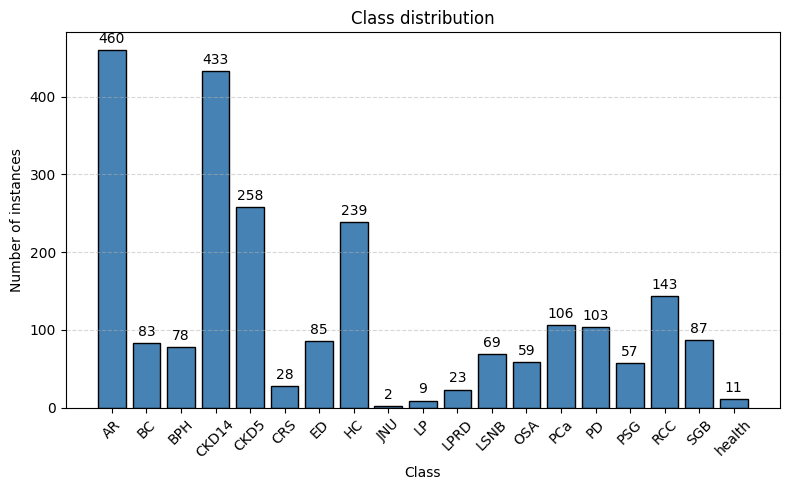

In [56]:
def plot_class_distribution(labels, class_names=None):
    """
    Plot the number of instances per class.

    Parameters
    ----------
    labels : array-like
        List or array of class labels.
    class_names : dict or list, optional
        Mapping from class id to class name.
    """
    labels = np.asarray(labels)

    # Count instances per class
    classes, counts = np.unique(labels, return_counts=True)

    # X-axis labels
    if class_names is None:
        x_labels = [str(c) for c in classes]
    elif isinstance(class_names, dict):
        x_labels = [class_names[c] for c in classes]
    else:
        x_labels = [class_names[c] for c in classes]

    # Plot
    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(
        x_labels,
        counts,
        color="steelblue",
        edgecolor="black",
    )

    # Display values on top of bars
    ax.bar_label(
        bars,
        fmt="%d",
        padding=3,
        fontsize=10,
        # fontweight="bold"
    )

    ax.set_xlabel("Class")
    ax.set_ylabel("Number of instances")
    ax.set_title("Class distribution")
    ax.tick_params(axis='x', labelrotation=45)

    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_class_distribution(groups_id)

### Classification

#### Data preparation

In [73]:
df_join_raw_intensity

,AR_2E,AR_A210050,AR_A210051,AR_A210052,AR_A210054,AR_A210055,AR_A210056,AR_A210057,AR_A210059,AR_A210062,...,health_S02,health_S03,health_S04,health_S05,health_S06,health_S07,health_S08,health_S09,health_S10,health_S11
0,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,-1.213064,-1.137626,-0.902078,-0.767949,...,-0.323119,-0.301910,0.197998,-0.335759,-0.189232,-0.178399,-0.167625,-0.156910,-0.146251,0.213709
1,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,1.525385,1.600685,1.835802,1.969684,...,2.399864,2.421034,2.920018,4.695384,2.305521,2.316318,2.327056,2.337737,2.348360,2.697953
2,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,0.323632,0.384811,0.575840,0.684617,...,1.138489,1.155690,1.561112,1.009244,1.087138,1.092894,1.098620,1.104314,1.109978,1.301124
3,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,0.848291,0.920234,1.144870,1.272785,...,1.880134,1.900361,2.377108,1.966174,2.072484,2.080343,2.088160,2.095934,2.103668,2.358324
4,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,0.603536,0.674229,0.887961,1.006285,...,1.507450,1.525407,1.944987,1.679141,1.785358,1.793208,1.801015,1.808780,1.816503,2.077151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7352,2.738059,0.896303,1.176526,1.472825,1.572100,1.654756,1.725780,1.788185,1.983040,2.093996,...,2.453639,2.471184,2.884720,2.212016,2.353521,2.363982,2.374387,2.384735,2.395029,2.733992
7353,0.955142,-0.859490,-0.578136,-0.280639,-0.180963,-0.097972,-0.026661,0.035996,0.231640,0.343045,...,0.703362,0.720978,1.136193,0.585522,0.676921,0.683676,0.690394,0.697076,0.703721,0.928008
7354,2.064099,0.180589,0.471322,0.778735,0.881734,0.967491,1.041179,1.105925,1.308089,1.423207,...,1.794745,1.812949,2.241999,1.546931,1.691106,1.701764,1.712365,1.722909,1.733396,2.087574
7355,0.995853,-0.396155,-0.179612,0.049355,0.126071,0.189944,0.244828,0.293052,0.443629,0.529371,...,0.819948,0.833506,1.153076,0.697635,0.776719,0.782563,0.788376,0.794157,0.799907,0.993974


In [59]:
df_join_raw_intensity.loc[:, df_join_raw_intensity.columns.str.contains("HC_")]

,HC_100,HC_102,HC_105,HC_106,HC_107,HC_108,HC_109,HC_11,HC_110,HC_111,...,HC_82,HC_85,HC_86,HC_87,HC_89,HC_92,HC_93,HC_95,HC_96,HC_97
0,-0.596597,-0.594119,-0.517086,-0.514603,-0.512119,-0.509636,-0.507152,-0.497681,-0.554414,-0.502182,...,-0.717125,-0.734880,-0.682670,-0.729955,-0.658036,-0.588926,-0.586454,-0.631255,-0.628782,-0.576561
1,3.720865,3.182973,2.827761,2.777970,2.767686,2.774118,2.676455,2.557895,2.600924,2.779730,...,3.115620,1.951505,2.260635,2.541524,1.780469,3.495325,3.430492,3.568087,3.373735,3.548949
2,0.689186,0.691305,0.784353,0.786473,0.788594,0.790715,0.792835,0.770604,0.725222,0.797078,...,0.619288,0.570699,0.642548,0.574928,0.663694,1.874726,0.722925,0.657424,0.659540,0.731392
3,1.065271,1.068019,1.184109,1.186855,1.189601,1.192347,1.195093,0.834812,1.111966,1.200584,...,0.958135,0.908226,0.996863,0.913754,1.024481,1.101644,1.104396,1.024026,1.026777,1.115401
4,0.829932,0.832295,0.934790,0.937163,0.939537,0.941912,0.944288,0.849208,0.870221,0.949042,...,0.742668,0.696391,0.775159,0.701041,0.798437,0.863960,0.866310,0.794569,0.796922,0.875718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7352,3.071785,3.116795,3.064273,3.216409,3.035825,3.279079,3.236918,2.440584,3.245978,3.443135,...,2.886766,1.833533,2.665168,2.766373,2.306135,2.889891,3.282568,3.251662,3.226558,3.287970
7353,1.012423,0.738276,0.663628,0.492902,0.664755,1.056817,0.665881,1.221071,0.665445,0.668135,...,0.589530,0.601411,0.604095,0.603652,0.771362,1.560145,0.640003,0.640688,0.641812,0.644499
7354,1.743210,1.851959,3.083411,2.492618,1.275504,2.372699,2.623214,2.349246,2.954943,2.108633,...,1.250689,1.825707,1.594401,1.249443,1.580890,2.114393,1.269073,1.260471,2.053923,1.658604
7355,0.597736,1.121106,1.005889,0.606885,1.043705,1.023356,0.607747,0.585502,0.873094,1.401561,...,0.579531,1.362563,1.364386,1.469004,1.077432,1.712657,0.968143,1.277563,0.592584,0.599148


In [74]:
df_join_raw_intensity_t = df_join_raw_intensity.T
df_join_raw_intensity_t

,0,1,2,3,4,5,6,7,8,9,...,7347,7348,7349,7350,7351,7352,7353,7354,7355,7356
AR_2E,0.575329,2.519698,0.580982,2.570505,1.157874,1.272133,2.620286,2.639902,2.650395,2.737571,...,3.492727,1.038678,4.094447,3.259059,2.839536,2.738059,0.955142,2.064099,0.995853,2.353579
AR_A210050,-2.215760,0.524517,-0.489549,-0.107955,-0.151374,0.103413,0.382952,0.465804,0.413413,0.575501,...,1.821854,-1.003702,-1.069380,1.463678,1.033401,0.896303,-0.859490,0.180589,-0.396155,0.677688
AR_A210051,-1.877019,0.862641,-0.214833,0.215094,0.127539,0.362454,0.635314,0.714628,0.672398,0.813973,...,2.079371,-0.676932,-0.694576,1.735775,1.305074,1.176526,-0.578136,0.471322,-0.179612,0.934525
AR_A210052,-1.518844,1.220163,0.075646,0.556676,0.297939,0.636357,0.902154,0.977727,0.946242,1.066128,...,2.351662,-0.331414,-0.298269,2.023482,1.592333,1.472825,-0.280639,0.778735,0.049355,1.206097
AR_A210054,-1.398838,1.339951,0.172970,0.671123,0.422454,0.728129,0.991559,1.065879,1.037993,1.150612,...,2.442892,-0.215649,-0.165487,2.119878,1.688579,1.572100,-0.180963,0.881734,0.126071,1.297087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
health_S07,-0.178399,2.316318,1.092894,2.080343,1.793208,1.864246,2.265994,2.432971,2.243914,2.482736,...,3.137960,0.677305,0.928202,2.920446,2.509182,2.363982,0.683676,1.701764,0.782563,1.993346
health_S08,-0.167625,2.327056,1.098620,2.088160,1.801015,1.871651,2.273323,2.440884,2.250869,2.491186,...,3.147583,0.691130,0.939115,2.930325,2.519404,2.374387,0.690394,1.712365,0.788376,2.004889
health_S09,-0.156910,2.337737,1.104314,2.095934,1.808780,1.879015,2.280612,2.448753,2.257787,2.499589,...,3.157155,0.704881,0.949969,2.940152,2.529572,2.384735,0.697076,1.722909,0.794157,2.016370
health_S10,-0.146251,2.348360,1.109978,2.103668,1.816503,1.886339,2.287862,2.456581,2.264667,2.507947,...,3.166675,0.718558,0.960764,2.949926,2.539684,2.395029,0.703721,1.733396,0.799907,2.027790


In [80]:
groups_id_unique = np.unique(groups_id)
groups_id_unique

array(['AR', 'BC', 'BPH', 'CKD14', 'CKD5', 'CRS', 'ED', 'HC', 'JNU', 'LP',
       'LPRD', 'LSNB', 'OSA', 'PCa', 'PD', 'PSG', 'RCC', 'SGB', 'health'],
      dtype='<U6')

#### Model selection and train

In [ ]:
param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 15),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5)
}

# Create a random forest classifier
model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(
    model, param_distributions=param_dist,
    n_iter=10, cv=5, scoring="accuracy",
    n_jobs=-1, random_state=42)

# Select and train model
search = rand_search.fit(X_train, y_train)

# Create a variable for the best model
best_model = rand_search.best_estimator_

# Print the best hyperparameters
print("Best hyperparameters:",  rand_search.best_params_)

#### Evaluation

In [ ]:
# Evaluation
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
recall_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")
classification_rep = classification_report(y_test, y_pred, output_dict=False)

print("Accuracy: ", accuracy)
print("Recall: ", recall_macro)
print("F1-score: ", f1_macro)

print(classification_rep)

In [ ]:
cm = confusion_matrix(y_test, y_pred)
class_names = best_model.classes_
tick_marks = np.arange(len(class_names))

plt.figure()
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
# plt.colorbar()
plt.xticks(tick_marks, class_names, rotation=45, ha="right", rotation_mode="anchor")
plt.yticks(tick_marks, class_names)

# Values inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            format(cm[i, j], "d"),
            ha="center",
            va="center"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Node classification

In [81]:
def visualize_(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

def visualize(h, color, class_names):
    z = TSNE(n_components=2, random_state=42).fit_transform(
        h.detach().cpu().numpy()
    )

    color = np.asarray(color)
    class_names = np.asarray(class_names)

    plt.figure(figsize=(10, 10))

    scatter = plt.scatter(
        z[:, 0],
        z[:, 1],
        c=color,
        cmap="tab20",
        s=70,
        alpha=0.8,
    )

    plt.xticks([])
    plt.yticks([])

    # Obtener una etiqueta por clase
    unique_classes = np.unique(color)
    handles = scatter.legend_elements()[0]

    labels = [
        class_names[color == c][0]
        for c in unique_classes
    ]

    plt.legend(
        handles,
        labels,
        title="Node types",
        loc="best"
    )

    plt.tight_layout()
    plt.show()
    
# Calculate accuracy
def accuracy(pred_y, y):
    return (pred_y == y).sum() / len(y)

In [ ]:
import torch

torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#### Preprocessing

In [151]:
df_join_raw_intensity_t = df_join_raw_intensity.T
df_join_raw_intensity_t

,0,1,2,3,4,5,6,7,8,9,...,7347,7348,7349,7350,7351,7352,7353,7354,7355,7356
AR_2E,0.575329,2.519698,0.580982,2.570505,1.157874,1.272133,2.620286,2.639902,2.650395,2.737571,...,3.492727,1.038678,4.094447,3.259059,2.839536,2.738059,0.955142,2.064099,0.995853,2.353579
AR_A210050,-2.215760,0.524517,-0.489549,-0.107955,-0.151374,0.103413,0.382952,0.465804,0.413413,0.575501,...,1.821854,-1.003702,-1.069380,1.463678,1.033401,0.896303,-0.859490,0.180589,-0.396155,0.677688
AR_A210051,-1.877019,0.862641,-0.214833,0.215094,0.127539,0.362454,0.635314,0.714628,0.672398,0.813973,...,2.079371,-0.676932,-0.694576,1.735775,1.305074,1.176526,-0.578136,0.471322,-0.179612,0.934525
AR_A210052,-1.518844,1.220163,0.075646,0.556676,0.297939,0.636357,0.902154,0.977727,0.946242,1.066128,...,2.351662,-0.331414,-0.298269,2.023482,1.592333,1.472825,-0.280639,0.778735,0.049355,1.206097
AR_A210054,-1.398838,1.339951,0.172970,0.671123,0.422454,0.728129,0.991559,1.065879,1.037993,1.150612,...,2.442892,-0.215649,-0.165487,2.119878,1.688579,1.572100,-0.180963,0.881734,0.126071,1.297087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
health_S07,-0.178399,2.316318,1.092894,2.080343,1.793208,1.864246,2.265994,2.432971,2.243914,2.482736,...,3.137960,0.677305,0.928202,2.920446,2.509182,2.363982,0.683676,1.701764,0.782563,1.993346
health_S08,-0.167625,2.327056,1.098620,2.088160,1.801015,1.871651,2.273323,2.440884,2.250869,2.491186,...,3.147583,0.691130,0.939115,2.930325,2.519404,2.374387,0.690394,1.712365,0.788376,2.004889
health_S09,-0.156910,2.337737,1.104314,2.095934,1.808780,1.879015,2.280612,2.448753,2.257787,2.499589,...,3.157155,0.704881,0.949969,2.940152,2.529572,2.384735,0.697076,1.722909,0.794157,2.016370
health_S10,-0.146251,2.348360,1.109978,2.103668,1.816503,1.886339,2.287862,2.456581,2.264667,2.507947,...,3.166675,0.718558,0.960764,2.949926,2.539684,2.395029,0.703721,1.733396,0.799907,2.027790


In [152]:
groups_id_unique = np.unique(groups_id)
groups_id_unique

array(['AR', 'BC', 'BPH', 'CKD14', 'CKD5', 'CRS', 'ED', 'HC', 'JNU', 'LP',
       'LPRD', 'LSNB', 'OSA', 'PCa', 'PD', 'PSG', 'RCC', 'SGB', 'health'],
      dtype='<U6')

##### Option 1 (partial correlations-LedoitWolf)

In [172]:
num_samples = 3 # Change
df_x_shuffled = df_join_raw_intensity_t.loc[df_join_raw_intensity_t.index.str.contains(f"{group_id}_"), :].sample(n=num_samples, axis=0, random_state=42)
df_x_shuffled

,0,1,2,3,4,5,6,7,8,9,...,7347,7348,7349,7350,7351,7352,7353,7354,7355,7356
health_S06,-0.189232,2.305521,1.087138,2.072484,1.785358,1.856800,2.258625,2.425015,2.236920,2.474240,...,3.128284,0.663404,0.917231,2.910513,2.498903,2.353521,0.676921,1.691106,0.776719,1.981739
health_S01,-0.871517,1.852474,0.693742,1.357142,1.034568,1.192117,1.541139,1.613431,1.578189,1.609192,...,2.824015,0.290288,0.385570,2.539341,2.117635,1.999986,0.247870,1.324074,0.469380,1.713877
health_S10,-0.146251,2.348360,1.109978,2.103668,1.816503,1.886339,2.287862,2.456581,2.264667,2.507947,...,3.166675,0.718558,0.960764,2.949926,2.539684,2.395029,0.703721,1.733396,0.799907,2.027790


In [173]:
# Partial correlation LedoitWolf

""" df_matrix = pg.pcorr(df_join_raw_intensity)
df_matrix """


from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
scaler = StandardScaler()

# df_subgroup_scaled = scaler.fit_transform(df_join_raw_intensity)
lw = LedoitWolf()
lw.fit(df_x_shuffled)

# Matriz de covarianza regularizada
cov = lw.covariance_
std = np.sqrt(np.diag(cov))
corr = cov / np.outer(std, std)
df_matrix = pd.DataFrame(corr)
df_matrix

,0,1,2,3,4,5,6,7,8,9,...,7347,7348,7349,7350,7351,7352,7353,7354,7355,7356
0,1.000000,0.369569,0.328154,0.481092,0.492529,0.462915,0.481444,0.510419,0.460318,0.524694,...,0.274342,0.326341,0.410082,0.319798,0.326649,0.309115,0.351006,0.318138,0.270673,0.250890
1,0.369569,1.000000,0.256930,0.376561,0.385497,0.362340,0.376815,0.399477,0.360290,0.410650,...,0.215089,0.255961,0.321232,0.250630,0.256003,0.242310,0.274847,0.249373,0.212000,0.196870
2,0.328154,0.256930,1.000000,0.334518,0.342473,0.321878,0.334766,0.354915,0.320075,0.364841,...,0.190708,0.226841,0.285107,0.222321,0.227083,0.214886,0.244050,0.221160,0.188188,0.174382
3,0.481092,0.376561,0.334518,1.000000,0.502190,0.471977,0.490893,0.520449,0.469344,0.535004,...,0.279424,0.332300,0.417907,0.325802,0.332778,0.314875,0.357793,0.324075,0.275861,0.255399
4,0.492529,0.385497,0.342473,0.502190,1.000000,0.483210,0.502579,0.532840,0.480516,0.547741,...,0.286042,0.340161,0.427831,0.333527,0.340669,0.322336,0.366299,0.331755,0.282414,0.261432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7352,0.309115,0.242310,0.214886,0.314875,0.322336,0.302987,0.315073,0.334013,0.301263,0.343355,...,0.180063,0.214341,0.268757,0.209759,0.214258,1.000000,0.229886,0.208733,0.177353,0.164909
7353,0.351006,0.274847,0.244050,0.357793,0.366299,0.344274,0.358055,0.379604,0.342343,0.390220,...,0.204025,0.242695,0.304978,0.237832,0.242927,0.229886,1.000000,0.236597,0.201300,0.186581
7354,0.318138,0.249373,0.221160,0.324075,0.331755,0.311839,0.324280,0.343774,0.310065,0.353390,...,0.185303,0.220573,0.276595,0.215870,0.220500,0.208733,0.236597,1.000000,0.182527,0.169699
7355,0.270673,0.212000,0.188188,0.275861,0.282414,0.265440,0.276056,0.292665,0.263946,0.300851,...,0.157413,0.187280,0.235217,0.183467,0.187398,0.177353,0.201300,0.182527,1.000000,0.144005


-0.983313371488116 1.0000000000000002


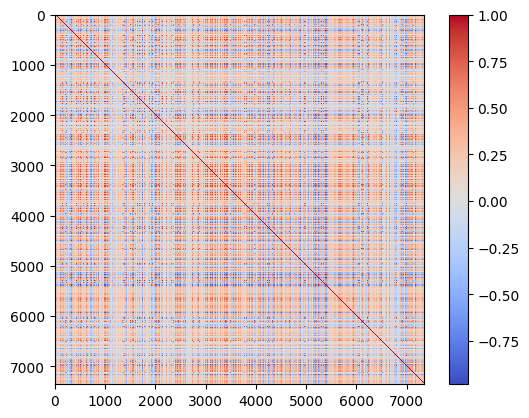

In [174]:
print(df_matrix.to_numpy().min(), df_matrix.to_numpy().max())

img = plt.imshow(
    df_matrix,
    cmap="coolwarm",
    interpolation="none",
)
plt.colorbar(img)

In [185]:
def create_directed_graph(df_matrix, umbral=0.1):
    names = df_matrix.index.to_numpy()
    values = df_matrix.to_numpy()

    mascara = np.triu(np.abs(values) >= umbral, k=1)
    i_idx, j_idx = np.nonzero(mascara)
    pesos = values[i_idx, j_idx]

    df = pd.DataFrame({"source": names[i_idx], "target": names[j_idx], "weight": pesos})
    return df.sort_values(["source", "target"], key=abs, ascending=True).reset_index(drop=True)

threshold = np.percentile(np.abs(df_matrix), 80) # Important
print(threshold)
df_weighted_edges = create_directed_graph(df_matrix, threshold)
df_weighted_edges

0.38340226860951604


,source,target,weight
0,0,3,0.481092
1,0,4,0.492529
2,0,5,0.462915
3,0,6,0.481444
4,0,7,0.510419
...,...,...,...
5408862,7340,7346,0.432500
5408863,7340,7349,0.396496
5408864,7342,7346,0.397457
5408865,7344,7346,0.387472


In [186]:
num_nodes = pd.concat([df_weighted_edges["source"], df_weighted_edges["target"]]).nunique()
num_nodes

4962

In [127]:
# Edge list

threshold = np.percentile(np.abs(df_matrix), 95) # Important

df_weighted_edges = (df_matrix.where(np.triu(np.ones(df_matrix.shape), k=1).astype(bool)).stack())
df_weighted_edges = df_weighted_edges.dropna().to_frame()
df_weighted_edges.reset_index(inplace=True)
df_weighted_edges.columns = ["source", "target", "weight"]
df_weighted_edges = df_weighted_edges[df_weighted_edges["weight"].abs() >= threshold]
df_weighted_edges


,source,target,weight
165,0,166,-0.678337
214,0,215,0.634657
295,0,296,0.646848
297,0,298,-0.657563
313,0,314,0.655051
...,...,...,...
27043004,7177,7246,0.650475
27043038,7177,7280,0.669363
27043081,7177,7323,0.644456
27048958,7214,7280,0.647627


In [134]:
num_nodes = pd.concat([df_weighted_edges["source"], df_weighted_edges["target"]]).nunique()
num_nodes

2927

##### Option 2 (partial correlations)

In [160]:
df_join_raw_intensity_t

,0,1,2,3,4,5,6,7,8,9,...,7347,7348,7349,7350,7351,7352,7353,7354,7355,7356
AR_2E,0.575329,2.519698,0.580982,2.570505,1.157874,1.272133,2.620286,2.639902,2.650395,2.737571,...,3.492727,1.038678,4.094447,3.259059,2.839536,2.738059,0.955142,2.064099,0.995853,2.353579
AR_A210050,-2.215760,0.524517,-0.489549,-0.107955,-0.151374,0.103413,0.382952,0.465804,0.413413,0.575501,...,1.821854,-1.003702,-1.069380,1.463678,1.033401,0.896303,-0.859490,0.180589,-0.396155,0.677688
AR_A210051,-1.877019,0.862641,-0.214833,0.215094,0.127539,0.362454,0.635314,0.714628,0.672398,0.813973,...,2.079371,-0.676932,-0.694576,1.735775,1.305074,1.176526,-0.578136,0.471322,-0.179612,0.934525
AR_A210052,-1.518844,1.220163,0.075646,0.556676,0.297939,0.636357,0.902154,0.977727,0.946242,1.066128,...,2.351662,-0.331414,-0.298269,2.023482,1.592333,1.472825,-0.280639,0.778735,0.049355,1.206097
AR_A210054,-1.398838,1.339951,0.172970,0.671123,0.422454,0.728129,0.991559,1.065879,1.037993,1.150612,...,2.442892,-0.215649,-0.165487,2.119878,1.688579,1.572100,-0.180963,0.881734,0.126071,1.297087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
health_S07,-0.178399,2.316318,1.092894,2.080343,1.793208,1.864246,2.265994,2.432971,2.243914,2.482736,...,3.137960,0.677305,0.928202,2.920446,2.509182,2.363982,0.683676,1.701764,0.782563,1.993346
health_S08,-0.167625,2.327056,1.098620,2.088160,1.801015,1.871651,2.273323,2.440884,2.250869,2.491186,...,3.147583,0.691130,0.939115,2.930325,2.519404,2.374387,0.690394,1.712365,0.788376,2.004889
health_S09,-0.156910,2.337737,1.104314,2.095934,1.808780,1.879015,2.280612,2.448753,2.257787,2.499589,...,3.157155,0.704881,0.949969,2.940152,2.529572,2.384735,0.697076,1.722909,0.794157,2.016370
health_S10,-0.146251,2.348360,1.109978,2.103668,1.816503,1.886339,2.287862,2.456581,2.264667,2.507947,...,3.166675,0.718558,0.960764,2.949926,2.539684,2.395029,0.703721,1.733396,0.799907,2.027790


In [136]:
groups_id_unique

array(['AR', 'BC', 'BPH', 'CKD14', 'CKD5', 'CRS', 'ED', 'HC', 'JNU', 'LP',
       'LPRD', 'LSNB', 'OSA', 'PCa', 'PD', 'PSG', 'RCC', 'SGB', 'health'],
      dtype='<U6')

In [113]:
group_id

'health'

In [161]:
num_samples = 3 # Change
df_x_shuffled = df_join_raw_intensity_t.loc[df_join_raw_intensity_t.index.str.contains(f"{group_id}_"), :].sample(n=num_samples, axis=0, random_state=42)
df_x_shuffled

,0,1,2,3,4,5,6,7,8,9,...,7347,7348,7349,7350,7351,7352,7353,7354,7355,7356
health_S06,-0.189232,2.305521,1.087138,2.072484,1.785358,1.856800,2.258625,2.425015,2.236920,2.474240,...,3.128284,0.663404,0.917231,2.910513,2.498903,2.353521,0.676921,1.691106,0.776719,1.981739
health_S01,-0.871517,1.852474,0.693742,1.357142,1.034568,1.192117,1.541139,1.613431,1.578189,1.609192,...,2.824015,0.290288,0.385570,2.539341,2.117635,1.999986,0.247870,1.324074,0.469380,1.713877
health_S10,-0.146251,2.348360,1.109978,2.103668,1.816503,1.886339,2.287862,2.456581,2.264667,2.507947,...,3.166675,0.718558,0.960764,2.949926,2.539684,2.395029,0.703721,1.733396,0.799907,2.027790


In [162]:
df_matrix = pg.pcorr(df_x_shuffled)
df_matrix

,0,1,2,3,4,5,6,7,8,9,...,7347,7348,7349,7350,7351,7352,7353,7354,7355,7356
0,1.000000,-0.998793,-0.999968,-0.999499,-0.999381,-0.999542,-0.999338,-0.999220,-0.999418,-0.999225,...,-0.995451,-0.992140,-0.999557,-0.997790,-0.997713,-0.996568,-1.000000,-0.996824,-0.999805,-0.987642
1,-0.998793,1.000000,-0.998371,-0.996738,-0.996448,-0.996850,-0.996344,-0.996075,-0.996537,-0.996085,...,-0.998929,-0.997088,-0.999812,-0.999849,-0.999829,-0.999431,-0.998751,-0.999532,-0.999568,-0.994147
2,-0.999968,-0.998371,1.000000,-0.999719,-0.999629,-0.999751,-0.999595,-0.999502,-0.999658,-0.999506,...,-0.994662,-0.991114,-0.999289,-0.997230,-0.997145,-0.995878,-0.999975,-0.996160,-0.999617,-0.986364
3,-0.999499,-0.996738,-0.999719,1.000000,-0.999994,-0.999999,-0.999989,-0.999969,-0.999997,-0.999970,...,-0.991935,-0.987681,-0.998115,-0.995186,-0.995074,-0.993447,-0.999525,-0.993804,-0.998679,-0.982185
4,-0.999381,-0.996448,-0.999629,-0.999994,1.000000,-0.999988,-0.999999,-0.999991,-0.999999,-0.999991,...,-0.991484,-0.987126,-0.997893,-0.994836,-0.994719,-0.993040,-0.999411,-0.993407,-0.998493,-0.981519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7352,-0.996568,-0.999431,-0.995878,-0.993447,-0.993040,-0.993607,-0.992895,-0.992521,-0.993165,-0.992536,...,-0.999921,-0.999093,-0.998589,-0.999866,-0.999884,1.000000,-0.996497,-0.999995,-0.998007,-0.997226
7353,-1.000000,-0.998751,-0.999975,-0.999525,-0.999411,-0.999568,-0.999368,-0.999253,-0.999447,-0.999258,...,-0.995369,-0.992033,-0.999532,-0.997733,-0.997655,-0.996497,1.000000,-0.996756,-0.999788,-0.987508
7354,-0.996824,-0.999532,-0.996160,-0.993804,-0.993407,-0.993959,-0.993266,-0.992902,-0.993529,-0.992916,...,-0.999877,-0.998954,-0.998752,-0.999913,-0.999927,-0.999995,-0.996756,1.000000,-0.998202,-0.996986
7355,-0.999805,-0.999568,-0.999617,-0.998679,-0.998493,-0.998750,-0.998425,-0.998246,-0.998550,-0.998253,...,-0.997137,-0.994417,-0.999950,-0.998907,-0.998853,-0.998007,-0.999788,-0.998202,1.000000,-0.990543


-1.0 1.0


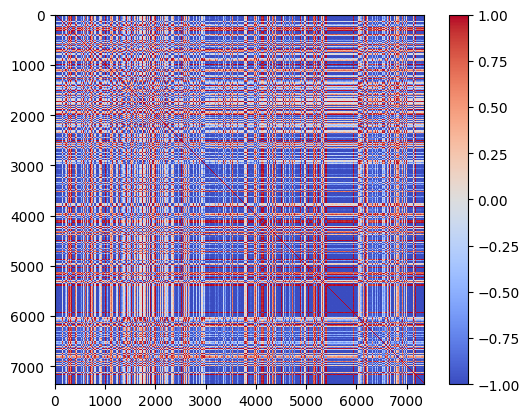

In [163]:
print(df_matrix.to_numpy().min(), df_matrix.to_numpy().max())

img = plt.imshow(
    df_matrix,
    cmap="coolwarm",
    interpolation="none",
)
plt.colorbar(img)

In [191]:
threshold = 0.92 # np.percentile(np.abs(df_matrix), 95) # Important
df_weighted_edges = create_directed_graph(df_matrix, threshold)
df_weighted_edges

,source,target,weight
0,99,116,0.952503
1,99,217,0.944178
2,99,246,0.940498
3,99,262,0.964723
4,99,307,-0.925660
...,...,...,...
31970,7104,7129,0.953371
31971,7104,7168,0.925235
31972,7104,7169,0.927609
31973,7107,7129,0.936911


In [190]:
num_nodes = pd.concat([df_weighted_edges["source"], df_weighted_edges["target"]]).nunique()
num_nodes

983

In [109]:
#  Create corpus graphs
num_samples = 3 # Change
for group_id in groups_id_unique:
    # get one by one
    df_x_shuffled = df_join_raw_intensity_t.loc[df_join_raw_intensity_t.index.str.contains(f"{group_id}_"), :].sample(n=num_samples, axis=0, random_state=42)
    df_x_shuffled
    
    # calculate correlation matrix
    matrix = pg.pcorr(df_x_shuffled)

,0,1,2,3,4,5,6,7,8,9,...,7347,7348,7349,7350,7351,7352,7353,7354,7355,7356
HC_105,-0.517086,2.827761,0.784353,1.184109,0.934790,1.135923,1.294309,1.310975,1.343729,1.412441,...,3.764254,0.546057,0.511007,3.478291,3.152876,3.064273,0.663628,3.083411,1.005889,2.025155
HC_44,0.580147,2.241897,1.676326,2.775282,2.432774,2.768454,2.795136,2.817363,2.926018,3.004878,...,3.100872,1.560325,1.614135,2.466319,2.682794,2.244348,0.714687,1.640980,1.557307,2.678677
HC_190,-0.125417,2.901738,1.120979,1.618264,1.317441,1.516976,1.663482,1.690290,1.734301,1.801481,...,3.529154,0.728836,0.606389,3.429524,2.053955,2.609359,1.993297,2.917910,1.508128,2.456727


In [ ]:
x1 = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]], dtype=torch.float)
edge_index1 = torch.tensor([[0, 1, 1, 2], [1, 0, 2, 1]], dtype=torch.long)
y1 = torch.tensor([0], dtype=torch.long)  # Etiqueta del grafo
graph1 = Data(x=x1, edge_index=edge_index1, y=y1)

##### Option 3 (K-NN)

In [ ]:
df_join_raw_intensity

In [ ]:
df_join_raw_intensity_t = df_join_raw_intensity.T
df_join_raw_intensity_t

In [ ]:
X = df_join_raw_intensity_t.values
X

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_join_raw_intensity_t.values)
X_scaled

In [ ]:
# similarity = cosine_similarity(X_scaled)
# similarity

In [ ]:
# Similarity matrix

k = 10 # Change

A = kneighbors_graph(
    X_scaled, # X, X_scaled
    n_neighbors=k,
    metric="cosine",
    mode="distance",
    include_self=False
)
A.toarray()

In [ ]:
# Edge list

edges = []

n = A.shape[0]

for i in range(n):
    for j in range(i + 1, n): # Solo parte superior (grafo no dirigido)
        if A[i, j] != 0:
            edges.append((i, j, A[i, j]))

print(edges)

df_weighted_edges = pd.DataFrame(edges, columns=["source", "target", "weight"])
df_weighted_edges

#### Data preparation

In [ ]:
df_weighted_edges

In [ ]:
edge_index = torch.tensor(df_weighted_edges.iloc[:, [0, 1]].values, dtype=torch.long)

data = Data(edge_index=edge_index.t().contiguous())

num_nodes = data.num_nodes
x = torch.eye(num_nodes, dtype=torch.float)
# x = torch.tensor(X_scaled, dtype=torch.float)
data.x = x

y = torch.tensor(pd.Series(groups_id).astype("category").cat.codes.values, dtype=torch.long)
data.y = y

# 2. Obtener los índices de todos los nodos en formato numpy
node_indices = torch.arange(num_nodes).numpy()
labels = data.y.numpy()

# 3. Dividir los índices usando sklearn (80% entrenamiento, 20% prueba)
# Puedes usar "stratify=labels" si quieres mantener la proporción de clases
train_idx, test_idx = train_test_split(
    node_indices, 
    test_size=0.2, 
    random_state=42, 
    stratify=labels
)

# 4. Crear las máscaras booleanas vacías (en falso)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

# 5. Cambiar a True las posiciones correspondientes a cada conjunto
train_mask[train_idx] = True
test_mask[test_idx] = True

# 6. Asignar las máscaras al objeto Data de PyTorch Geometric
data.train_mask = train_mask
data.test_mask = test_mask
data

In [ ]:
print(data)
print()

# Gather some statistics about the graph.
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Average node degree: {data.num_edges / data.num_nodes:.2f}")
print(f"Number of training nodes: {data.train_mask.sum()}")
print(f"Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}")
print(f"Contains isolated nodes: {data.has_isolated_nodes()}")
print(f"Contains self-loops: {data.has_self_loops()}")
print(f"Is undirected: {data.is_undirected()}")

In [ ]:
transform = T.Compose([T.ToUndirected()])#, T.AddSelfLoops()])
data = transform(data) 

print(data)
print()

# Gather some statistics about the graph.
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Average node degree: {data.num_edges / data.num_nodes:.2f}")
print(f"Number of training nodes: {data.train_mask.sum()}")
print(f"Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}")
print(f"Contains isolated nodes: {data.has_isolated_nodes()}")
print(f"Contains self-loops: {data.has_self_loops()}")
print(f"Is undirected: {data.is_undirected()}")

In [ ]:
data.x.shape, data.x.size(-1), data.num_features

In [ ]:
num_features = data.num_features # data.x.size(-1)

# 2. Obtener el número de clases (valores únicos en el tensor y)
if data.y.dim() <= 1:
    # Para clasificación de nodos o grafos con etiquetas discretas
    num_classes = int(data.y.max()) + 1
else:
    # Para etiquetas representadas en formato one-hot o multi-label
    num_classes = data.y.size(-1)

print(f"Number of features: {num_features}")
print(f"Number of classes: {num_classes}")

In [ ]:
# Número de nodos por clase en el conjunto de entrenamiento
unique, counts = torch.unique(
    data.y[data.train_mask],
    return_counts=True
)

classes = unique.cpu().numpy()
counts = counts.cpu().numpy()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    classes.astype(str),
    counts,
    color="steelblue",
    edgecolor="black"
)

# Mostrar el número de nodos sobre cada barra
plt.bar_label(
    bars,
    fmt="%d",
    padding=3,
    fontsize=10,
    # fontweight="bold"
)

plt.xlabel("Class")
plt.ylabel("Number of training nodes")
plt.title("Training node distribution by class")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# Número de nodos por clase en el conjunto de entrenamiento
unique, counts = torch.unique(
    data.y[data.test_mask],
    return_counts=True
)

classes = unique.cpu().numpy()
counts = counts.cpu().numpy()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    classes.astype(str),
    counts,
    color="steelblue",
    edgecolor="black"
)

# Mostrar el número de nodos sobre cada barra
plt.bar_label(
    bars,
    fmt="%d",
    padding=3,
    fontsize=10,
    # fontweight="bold"
)

plt.xlabel("Class")
plt.ylabel("Number of training nodes")
plt.title("Testing node distribution by class")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### GCN

In [ ]:
# Define GCN

class GCN(torch.nn.Module):
    def __init__(self, num_features, dim_h, num_classes):
        super(GCN, self).__init__()
        torch.manual_seed(42)
        self.conv1 = GCNConv(num_features, 1024)
        self.conv2 = GCNConv(1024, 128)
        self.conv3 = GCNConv(128, dim_h)
        self.classifier = Linear(dim_h, num_classes)

    def forward(self, x, edge_index):
        # Node embeddings
        h = self.conv1(x, edge_index)
        h = h.relu()
        h = self.conv2(h, edge_index)
        h = h.relu()
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.conv3(h, edge_index)
        z = h.relu()  # final GNN embedding space

        # Prediction head: linear classifier
        out = self.classifier(z)

        return out, z

# Hyperparameters
dimension = 128 # dimension of node embeddings
number_features = num_features # dimension of node features
number_classes = num_classes # number of classes

model = GCN(num_features=number_features, dim_h=dimension, num_classes=number_classes)
print(model)

In [ ]:
# Vizualization
model.eval()
out, z = model(data.x, data.edge_index)

visualize(z, data.y, groups_id)

In [ ]:
# Train

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)#, weight_decay=5e-4)

# Data for animations
embeddings = []
losses = []
accuracies = []
outputs = []
epochs = 1000

# Training loop
pbar = tqdm(range(1, epochs + 1))
for epoch in pbar:
    # Mode train
    model.train()
    
    # Clear gradients
    optimizer.zero_grad()

    # Forward pass
    out, z = model(data.x, data.edge_index)

    # Calculate loss function
    # loss = criterion(out, data.y)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])

    # Calculate accuracy
    acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])

    # Compute gradients
    loss.backward()

    # Tune parameters
    optimizer.step()

    # Store data for animations
    embeddings.append(z)
    losses.append(loss.item())
    accuracies.append(acc)
    outputs.append(out.argmax(dim=1))

    # Print metrics
    pbar.set_description(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%")

    # Print metrics every 10 epochs
    """ if epoch % 10 == 0:
        print(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%") """

In [ ]:
# Model evaluation
model.eval()
out, z = model(data.x, data.edge_index)
acc = accuracy(out[data.test_mask].argmax(dim=1), data.y[data.test_mask])
print(f"Acc: {acc*100:.2f}%")

In [ ]:
# Get node embeddings
print(z.shape)
z

In [ ]:
# Plot loss curve
plt.figure()
plt.plot(range(1, epochs + 1), losses, marker="")

# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Title
plt.title("Training loss curve")

# Grid for better visualization
plt.grid(True)

# Display plot
plt.show()

In [ ]:
# Plot accuracy curve
plt.figure()
plt.plot(range(1, epochs + 1), accuracies, marker="")

# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Title
plt.title("Training accuracy curve")

# Grid for better visualization
plt.grid(True)

# Display plot
plt.show()

In [ ]:
visualize(z, data.y, groups_id)

#### GAT

In [ ]:
# Define GAT
class GAT(torch.nn.Module):
    def __init__(self, num_features, dim_h, num_classes, heads=1):
        super(GAT, self).__init__()
        torch.manual_seed(42)
        # GAT layers
        """ self.conv1 = GATv2Conv(num_features, 512, heads=heads)
        self.conv2 = GATv2Conv(512 * heads, 64, heads=heads)
        self.conv3 = GATv2Conv(64 * heads, dim_h, heads=1) """
        
        """ self.conv1 = GATv2Conv(num_features, 64, heads=4)
        self.conv2 = GATv2Conv(64 * 4, 64, heads=4)
        self.conv3 = GATv2Conv(64 * 4, dim_h, heads=1) """
        
        self.conv1 = GATv2Conv(
            num_features,
            64,
            heads=4,
            dropout=0.6
        )

        self.conv2 = GATv2Conv(
            64 * 4,
            dim_h,
            heads=1,
            concat=False,
            dropout=0.6
        )
        
        # Prediction head
        self.classifier = Linear(dim_h, num_classes)

    def forward(self, x, edge_index):
        # Node embeddings
        """ h = self.conv1(x, edge_index)
        h = h.relu()
        h = self.conv2(h, edge_index)
        h = h.relu()
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.conv3(h, edge_index)
        z = h.relu()  # final GNN embedding space """
        
        """ h = self.conv1(x, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.conv2(h, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=0.5, training=self.training)
        z = self.conv3(h, edge_index) """
        
        """ x = F.dropout(x, 0.6, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, 0.6, training=self.training)
        z = self.conv2(x, edge_index) """
        
        h = self.conv1(x, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=0.6, training=self.training)
        h = self.conv2(h, edge_index)
        z = F.elu(h)
        
        # Prediction head: linear classifier
        out = self.classifier(z)
        return out, z

# Hyperparameters
dimension = 128 # node embedding dimension d'
num_features = num_features # input feature dimension d
num_classes = num_classes # number of output classes |Y|
num_heads = 2 # number of attention heads K

# Model instantiation
model = GAT(
    num_features = num_features,
    dim_h        = dimension,
    num_classes  = num_classes,
    heads        = num_heads
)
print(model)

In [ ]:
# Vizualization
model.eval()
out, z = model(data.x, data.edge_index)

visualize(z, data.y, groups_id)

In [ ]:
# Train

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)#, weight_decay=5e-4)

# Data for animations
embeddings = []
losses = []
accuracies = []
outputs = []
epochs = 1000

# Training loop
pbar = tqdm(range(1, epochs + 1))
for epoch in pbar:
    # Mode train
    model.train()

    # Clear gradients
    optimizer.zero_grad()

    # Forward pass
    out, z = model(data.x, data.edge_index)

    # Calculate loss function
    loss = criterion(out[data.train_mask], data.y[data.train_mask])

    # Calculate accuracy
    acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])

    # Compute gradients
    loss.backward()

    # Tune parameters
    optimizer.step()

    # Store data for animations
    embeddings.append(z)
    losses.append(loss.item())
    accuracies.append(acc)
    outputs.append(z.argmax(dim=1))

    # Print metrics
    pbar.set_description(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%")

    # Print metrics every 10 epochs
    """ if epoch % 10 == 0:
        print(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%") """

In [ ]:
# Model evaluation
model.eval()
out, z = model(data.x, data.edge_index)
acc = accuracy(out[data.test_mask].argmax(dim=1), data.y[data.test_mask])
print(f"Acc: {acc*100:.2f}%")

In [ ]:
model.eval()
with torch.no_grad():
    # 2. Obtener las predicciones del modelo (log_softmax o logits)
    out, z = model(data.x, data.edge_index)
    
    # 3. Convertir las salidas en las clases predichas (índice con mayor valor)
    y_pred = out.argmax(dim=1)

# 4. Filtrar solo los nodos del conjunto de prueba (Test Set)
# Usamos .cpu().numpy() porque scikit-learn trabaja con vectores de NumPy
y_test = data.y[data.test_mask].cpu().numpy()
y_pred = y_pred[data.test_mask].cpu().numpy()

accuracy = accuracy_score(y_test, y_pred)
recall_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")
classification_rep = classification_report(y_test, y_pred, output_dict=False)

print("Accuracy: ", accuracy)
print("Recall: ", recall_macro)
print("F1-score: ", f1_macro)

print(classification_rep)

# 5. Calcular la matriz de confusión numérica
cm = confusion_matrix(y_test, y_pred)
# print("Confusion Matrix:\n", cm)

labels = [f"{i}" for i in range(out.shape[1])] 

disp = ConfusionMatrixDisplay(confusion_matrix=cm) # , display_labels=labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title("Matriz de Confusión - Clasificación de Nodos")
plt.show()

In [ ]:
# Get node embeddings
print(z.shape)
z

In [ ]:
# Plot loss curve
plt.figure()
plt.plot(range(1, epochs + 1), losses, marker="")

# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Title
plt.title("Training loss curve")

# Grid for better visualization
plt.grid(True)

# Display plot
plt.show()

In [ ]:
# Plot accuracy curve
plt.figure()
plt.plot(range(1, epochs + 1), accuracies, marker="")

# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Title
plt.title("Training accuracy curve")

# Grid for better visualization
plt.grid(True)

# Display plot
plt.show()

In [ ]:
visualize(z, data.y, groups_id)